# Concept-flipping — results

Visualisations for the concept-flipping experiment (paper §Concept-flipping).
Data: `data/results/concept_flipping/flipping_<dataset>.parquet` (+ `meta.json`),
generated by `experiments/concept_flipping.py`.

**Setup**: CP-LRP (`composite_lxt`) relevance · `HeadConcept` (attention heads)
read at `proj_drop` · all 12 blocks · 3 datasets · N=50 correctly-classified
images/class · perturbations `zero` / `mean` / `sign_flip` · orderings
`most`/`least`-relevant-first.

**Curve**: `Δ(n) = y'_c / y_c` (target-class logit after perturbing `n` heads,
relative to intact). **Score** = `Σ_n (Δ_least − Δ_most)` (area; large ⇒ relevance
concentrated in few heads). **Correlation** of Δ with cumulative relevance tests
whether relevance ∝ influence.

In [1]:
import json, glob
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT/'pyproject.toml').is_file(): ROOT = ROOT.parent
DATA = ROOT/'data'/'results'/'concept_flipping'
meta = json.loads((DATA/'meta.json').read_text())
df = pl.concat([pl.read_parquet(f) for f in sorted(glob.glob(str(DATA/'flipping_*.parquet')))])
print('rows', df.height)
print('datasets', df['dataset'].unique().to_list())
print('perturbations', df['perturbation'].unique().to_list())
print('blocks', sorted(df['block'].unique().to_list()))
df.head(3)

rows 1587600
datasets ['dsprites', 'colored_mnist', 'funny_birds']
perturbations ['zero', 'mean', 'sign_flip']
blocks [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


dataset,perturbation,ordering,block,layer,class,image_idx,n,logit_target,prob_target,logit_baseline,prob_baseline,cum_relevance,rel_total,num_heads,delta_logit,delta_prob
str,str,str,i64,str,i64,i64,i64,f64,f64,f64,f64,f64,f64,i64,f64,f64
"""colored_mnist""","""zero""","""most""",0,"""backbone.blocks.0.attn.proj_dr…",0,41291,0,4.508744,0.920959,4.508744,0.920959,0.0,0.503873,6,1.0,1.0
"""colored_mnist""","""zero""","""most""",0,"""backbone.blocks.0.attn.proj_dr…",0,41291,1,5.077996,0.947277,4.508744,0.920959,0.110443,0.503873,6,1.126255,1.028577
"""colored_mnist""","""zero""","""most""",0,"""backbone.blocks.0.attn.proj_dr…",0,41291,2,4.965173,0.932541,4.508744,0.920959,0.219094,0.503873,6,1.101232,1.012576


## 1. Flipping curves Δ(n) — most vs least, per block (zero-ablation)

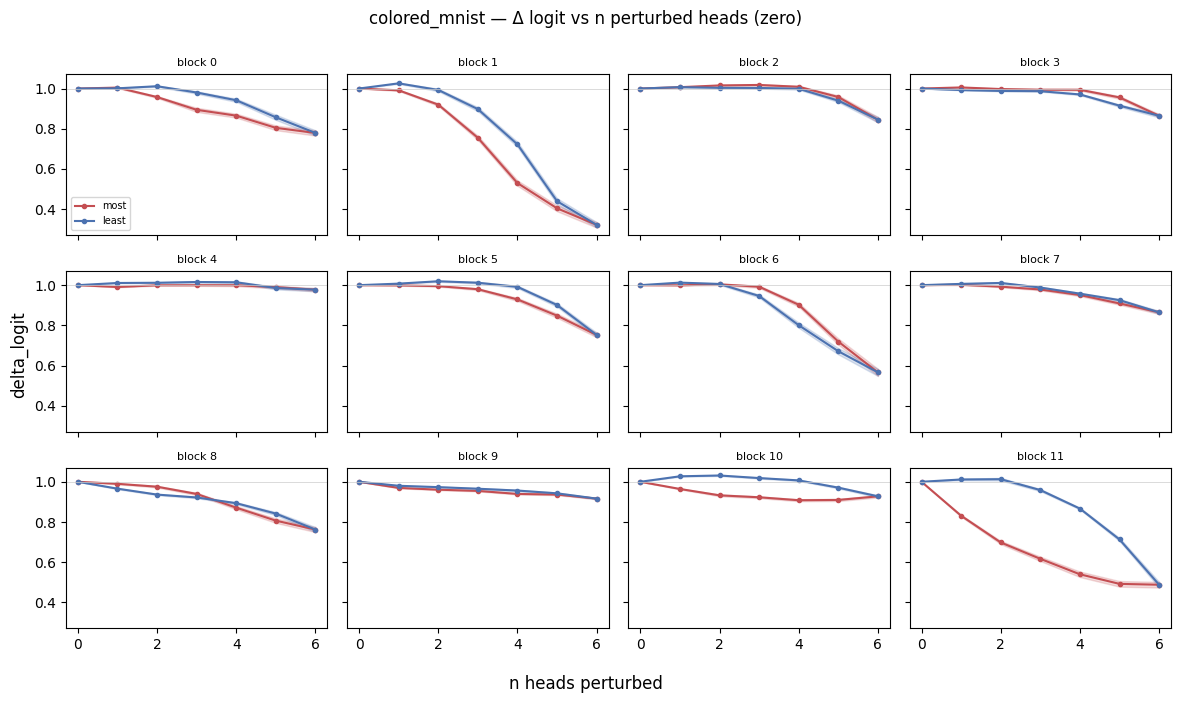

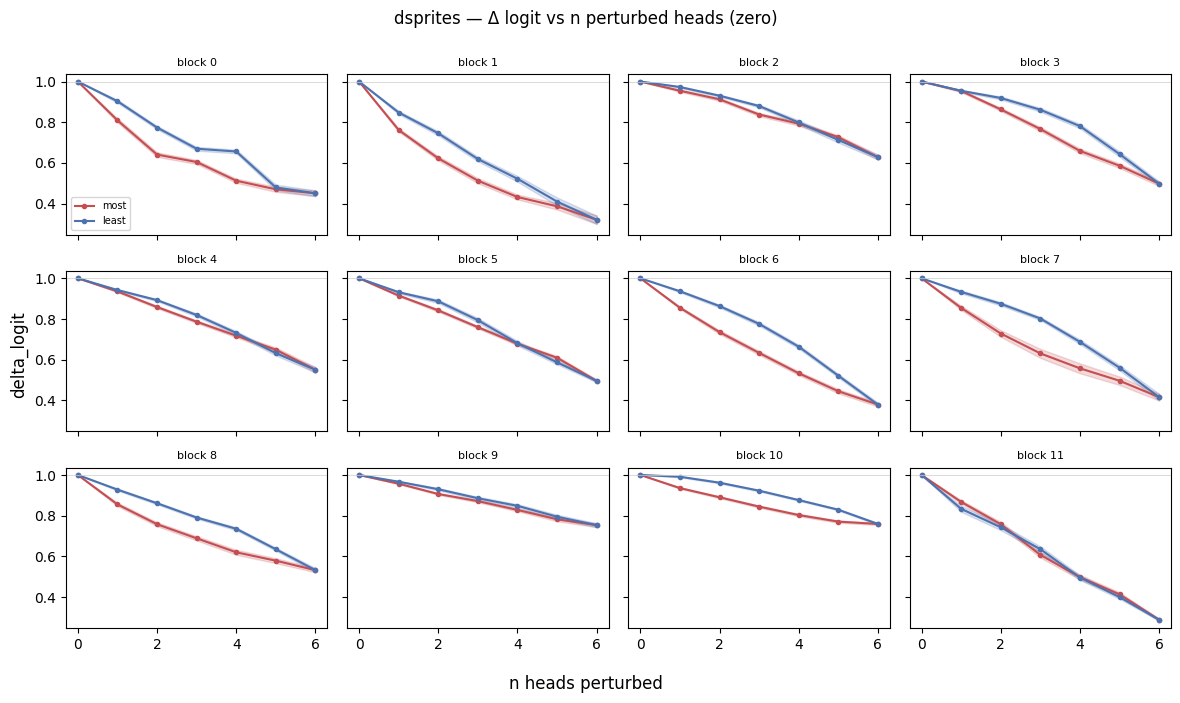

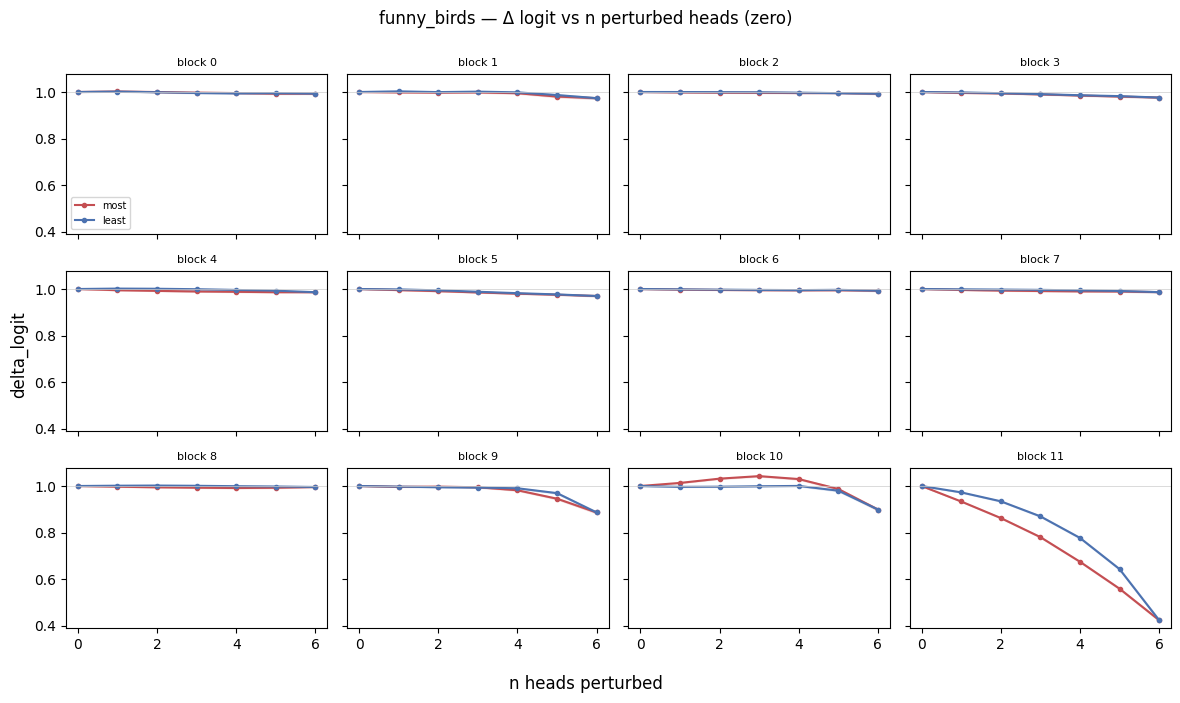

In [2]:
def curve_grid(pert='zero', scale='delta_logit'):
    for ds in df['dataset'].unique().sort().to_list():
        d = df.filter((pl.col('dataset')==ds)&(pl.col('perturbation')==pert))
        blocks = sorted(d['block'].unique().to_list())
        agg = (d.group_by(['block','ordering','n'])
                 .agg(pl.col(scale).mean().alias('m'),
                      (pl.col(scale).std()/pl.col(scale).count().sqrt()).alias('se'))
                 .sort(['block','ordering','n']))
        ncol=4; nrow=int(np.ceil(len(blocks)/ncol))
        fig,axes=plt.subplots(nrow,ncol,figsize=(3*ncol,2.3*nrow),sharex=True,sharey=True)
        axes=np.atleast_1d(axes).ravel()
        for ax,b in zip(axes,blocks):
            for o,col in [('most','#C44E52'),('least','#4C72B0')]:
                s=agg.filter((pl.col('block')==b)&(pl.col('ordering')==o)).sort('n')
                n=s['n'].to_numpy(); m=s['m'].to_numpy(); se=s['se'].to_numpy()
                ax.plot(n,m,color=col,label=o,marker='.')
                ax.fill_between(n,m-se,m+se,color=col,alpha=0.2)
            ax.set_title(f'block {b}',fontsize=8); ax.axhline(1,color='0.8',lw=0.5)
        for ax in axes[len(blocks):]: ax.axis('off')
        axes[0].legend(fontsize=7)
        fig.suptitle(f'{ds} — Δ {scale.split("_")[1]} vs n perturbed heads ({pert})',y=1.0)
        fig.supxlabel('n heads perturbed'); fig.supylabel(scale)
        fig.tight_layout(); plt.show()

curve_grid('zero','delta_logit')

## 2. Concept-flipping score per block\nScore = Σ_n (Δ_least − Δ_most). Higher ⇒ relevance concentrated, ranking predictive.

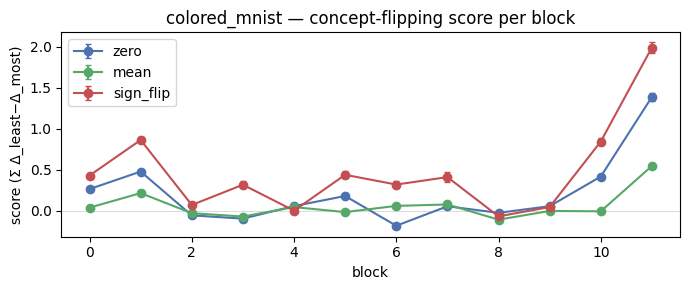

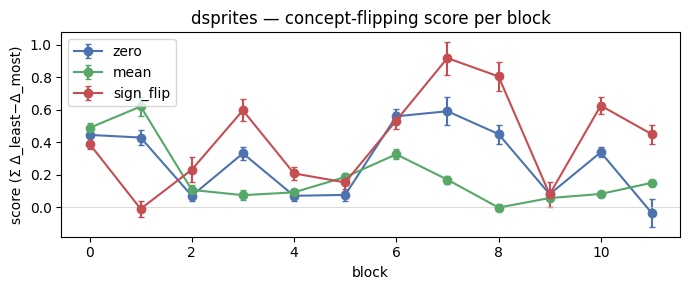

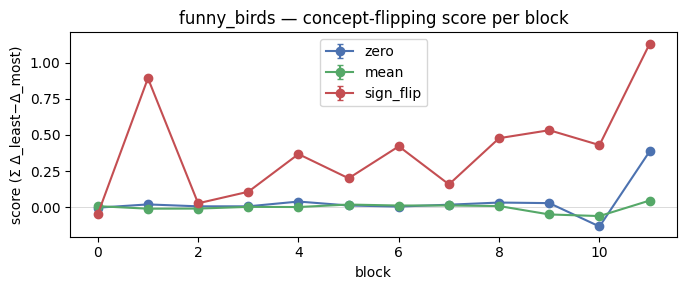

In [3]:
def flip_score(scale='delta_logit'):
    # per (dataset, perturbation, block, image): area between least & most curves
    piv = (df.group_by(['dataset','perturbation','block','image_idx','ordering'])
             .agg(pl.col(scale).sum().alias('auc'))   # Σ_n Δ(n) per image-curve
             .pivot(values='auc', index=['dataset','perturbation','block','image_idx'], on='ordering'))
    piv = piv.with_columns((pl.col('least')-pl.col('most')).alias('score'))
    return piv
sc = flip_score()
agg = sc.group_by(['dataset','perturbation','block']).agg(
        pl.col('score').mean().alias('m'),
        (pl.col('score').std()/pl.col('score').count().sqrt()).alias('se')).sort(['dataset','perturbation','block'])
for ds in agg['dataset'].unique().sort().to_list():
    fig,ax=plt.subplots(figsize=(7,3))
    for pert,col in [('zero','#4C72B0'),('mean','#55A868'),('sign_flip','#C44E52')]:
        s=agg.filter((pl.col('dataset')==ds)&(pl.col('perturbation')==pert)).sort('block')
        ax.errorbar(s['block'],s['m'],yerr=s['se'],marker='o',capsize=2,label=pert,color=col)
    ax.set_title(f'{ds} — concept-flipping score per block'); ax.set_xlabel('block'); ax.set_ylabel('score (Σ Δ_least−Δ_most)')
    ax.axhline(0,color='0.8',lw=0.5); ax.legend(); fig.tight_layout(); plt.show()

## 3. Perturbation-method comparison (last block)

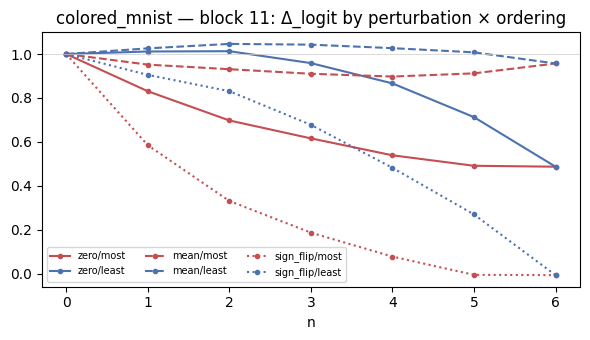

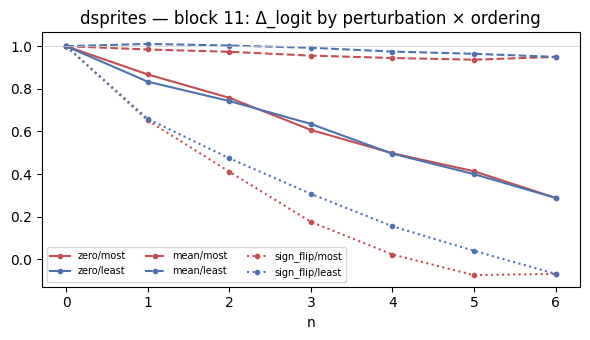

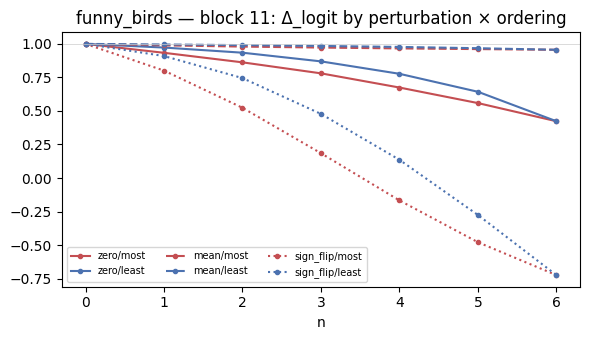

In [4]:
last = df.select(pl.col('block').max()).item()
for ds in df['dataset'].unique().sort().to_list():
    d=df.filter((pl.col('dataset')==ds)&(pl.col('block')==last))
    fig,ax=plt.subplots(figsize=(6,3.5))
    for pert,ls in [('zero','-'),('mean','--'),('sign_flip',':')]:
        for o,col in [('most','#C44E52'),('least','#4C72B0')]:
            s=(d.filter((pl.col('perturbation')==pert)&(pl.col('ordering')==o))
                 .group_by('n').agg(pl.col('delta_logit').mean()).sort('n'))
            ax.plot(s['n'],s['delta_logit'],ls,color=col,marker='.',label=f'{pert}/{o}')
    ax.set_title(f'{ds} — block {last}: Δ_logit by perturbation × ordering'); ax.set_xlabel('n'); ax.axhline(1,color='0.8',lw=0.5)
    ax.legend(fontsize=7,ncol=3); fig.tight_layout(); plt.show()

## 4. Score per class × block (heatmap) — relevance concentration by class

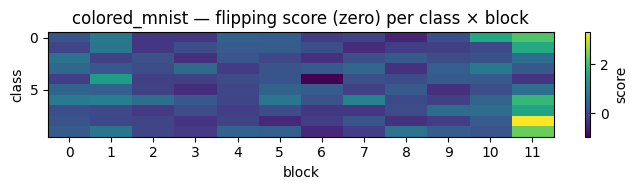

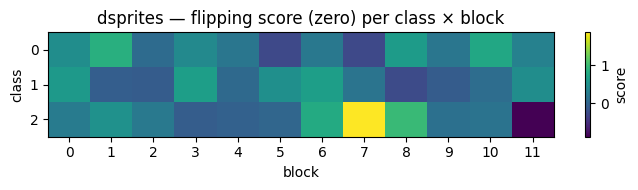

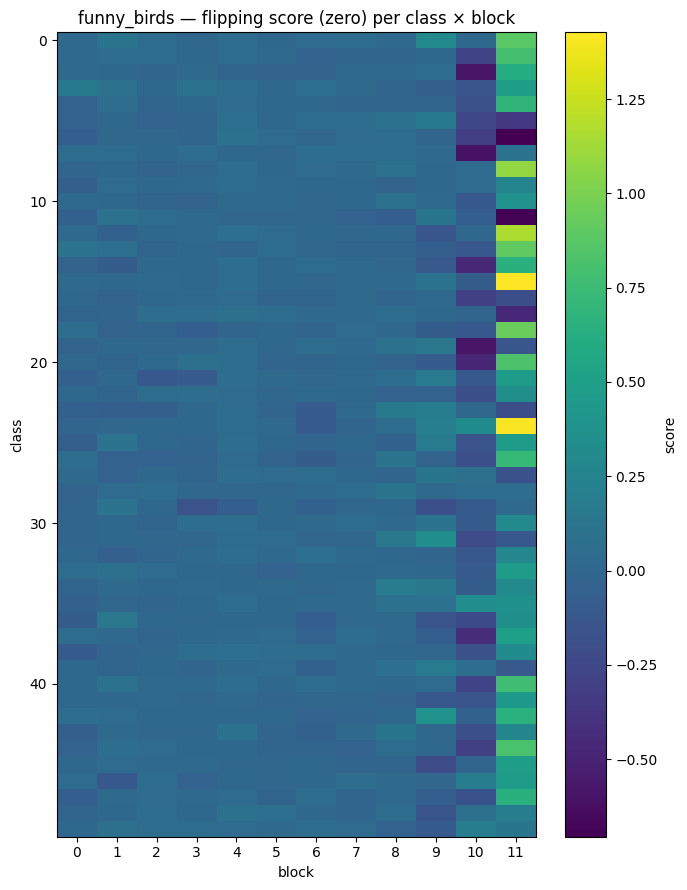

In [5]:
for ds in df['dataset'].unique().sort().to_list():
    s=(flip_score().join(df.select(['image_idx','dataset','class']).unique(),
                          on=['dataset','image_idx'])
        if 'class' not in flip_score().columns else None)
    # recompute score keeping class
    piv=(df.filter(pl.col('dataset')==ds).filter(pl.col('perturbation')=='zero')
           .group_by(['class','block','image_idx','ordering'])
           .agg(pl.col('delta_logit').sum().alias('auc'))
           .pivot(values='auc',index=['class','block','image_idx'],on='ordering')
           .with_columns((pl.col('least')-pl.col('most')).alias('score'))
           .group_by(['class','block']).agg(pl.col('score').mean()).sort(['class','block']))
    classes=sorted(piv['class'].unique().to_list()); blocks=sorted(piv['block'].unique().to_list())
    M=np.full((len(classes),len(blocks)),np.nan)
    ci={c:i for i,c in enumerate(classes)}; bi={b:i for i,b in enumerate(blocks)}
    for r in piv.iter_rows(named=True): M[ci[r['class']],bi[r['block']]]=r['score']
    fig,ax=plt.subplots(figsize=(7,max(2,0.18*len(classes))))
    im=ax.imshow(M,aspect='auto',cmap='viridis'); fig.colorbar(im,ax=ax,label='score')
    ax.set_xticks(range(len(blocks))); ax.set_xticklabels(blocks); ax.set_xlabel('block')
    ax.set_ylabel('class'); ax.set_title(f'{ds} — flipping score (zero) per class × block'); fig.tight_layout(); plt.show()

## 5. Correlation: Δ vs cumulative relevance\nMean per-image Pearson corr between Δ_most(n) and cumulative relevance of the perturbed heads (n=1..6). Tests hypothesis *relevance ∝ influence*.

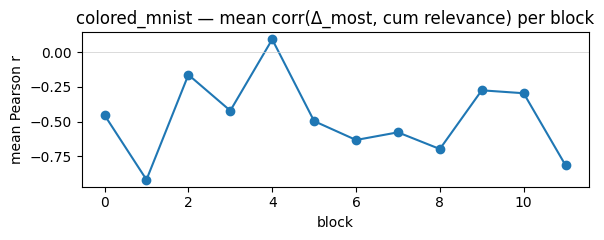

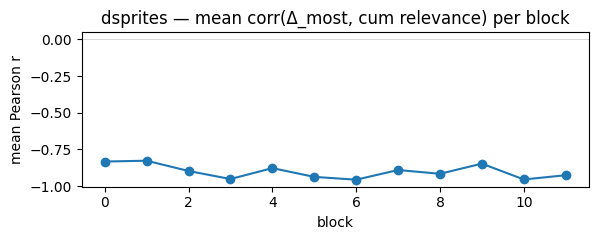

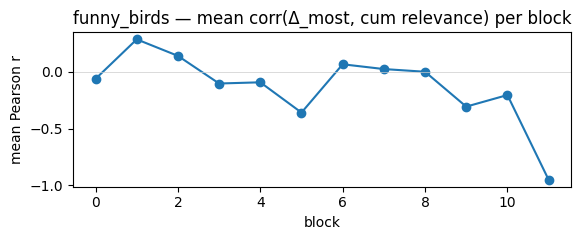

dataset,block,mean_corr,n_img
str,i64,f64,i64
"""colored_mnist""",0,-0.453497,500
"""colored_mnist""",1,-0.919585,500
"""colored_mnist""",2,-0.161908,500
"""colored_mnist""",3,-0.421289,500
"""colored_mnist""",4,0.093736,500
…,…,…,…
"""funny_birds""",7,0.024775,2500
"""funny_birds""",8,0.001039,2500
"""funny_birds""",9,-0.306187,2500


In [6]:
def corr_table(pert='zero'):
    d=df.filter((pl.col('perturbation')==pert)&(pl.col('ordering')=='most')&(pl.col('n')>0))
    out=[]
    for (ds,b),g in d.group_by(['dataset','block']):
        cs=[]
        for (_,),gi in g.group_by(['image_idx']):
            x=gi.sort('n')['cum_relevance'].to_numpy(); y=gi.sort('n')['delta_logit'].to_numpy()
            if x.std()>0 and y.std()>0: cs.append(np.corrcoef(x,y)[0,1])
        if cs: out.append(dict(dataset=ds,block=b,mean_corr=float(np.mean(cs)),n_img=len(cs)))
    return pl.DataFrame(out).sort(['dataset','block'])
ct=corr_table('zero')
for ds in ct['dataset'].unique().sort().to_list():
    s=ct.filter(pl.col('dataset')==ds).sort('block')
    plt.figure(figsize=(6,2.5)); plt.plot(s['block'],s['mean_corr'],marker='o')
    plt.axhline(0,color='0.8',lw=0.5); plt.title(f'{ds} — mean corr(Δ_most, cum relevance) per block')
    plt.xlabel('block'); plt.ylabel('mean Pearson r'); plt.tight_layout(); plt.show()
ct